In [1]:
import pandas
import numpy
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print("Device:", device)

Device: mps


In [2]:
with open("/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S1/S1.pkl", "rb") as f:
    data =  pickle.load(f, encoding="latin1")
data

/var/folders/y8/q2s37ndx6tg3lpzp3vp8xk_r0000gn/T/ipykernel_13546/2847764789.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data =  pickle.load(f, encoding="latin1")


{'rpeaks': array([    240,    1174,    2128, ..., 6447292, 6447748, 6448224],
       shape=(11431,), dtype=int32),
 'signal': {'chest': {'ACC': array([[ 0.85640001, -0.06779999, -0.36559999],
          [ 0.8556    , -0.06900001, -0.3646    ],
          [ 0.852     , -0.07020003, -0.3642    ],
          ...,
          [ 0.88759995, -0.1038    , -0.27920002],
          [ 0.88619995, -0.10159999, -0.27819997],
          [ 0.88680005, -0.10140002, -0.27380002]], shape=(6448400, 3)),
   'ECG': array([[0.01560974],
          [0.01812744],
          [0.01753235],
          ...,
          [0.21368408],
          [0.21556091],
          [0.21702576]], shape=(6448400, 1)),
   'EMG': array([[-1.5],
          [-1.5],
          [-1.5],
          ...,
          [-1.5],
          [-1.5],
          [-1.5]], shape=(6448400, 1)),
   'EDA': array([[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]], shape=(6448400, 1)),
   'Temp': array([[-273.15],
       

In [3]:
data["signal"]["chest"]["ECG"]#.keys()

array([[0.01560974],
       [0.01812744],
       [0.01753235],
       ...,
       [0.21368408],
       [0.21556091],
       [0.21702576]], shape=(6448400, 1))

In [4]:
data["signal"]["wrist"]#.keys()

{'ACC': array([[-0.765625, -0.078125,  0.671875],
        [-0.765625, -0.078125,  0.65625 ],
        [-0.765625, -0.078125,  0.671875],
        ...,
        [-0.375   , -0.015625,  0.9375  ],
        [-0.390625,  0.      ,  0.9375  ],
        [-0.375   ,  0.      ,  0.9375  ]], shape=(294784, 3)),
 'BVP': array([[  7.28],
        [  6.33],
        [  5.46],
        ...,
        [105.02],
        [109.44],
        [111.06]], shape=(589568, 1)),
 'EDA': array([[4.722437],
        [4.728843],
        [4.718594],
        ...,
        [3.170867],
        [3.159336],
        [3.151649]], shape=(36848, 1)),
 'TEMP': array([[32.13],
        [32.16],
        [32.16],
        ...,
        [34.37],
        [34.37],
        [34.37]], shape=(36848, 1))}

In [5]:
data["label"]

array([49.61136908, 50.32399248, 52.70833578, ..., 84.004991  ,
       85.79625673, 87.4113988 ], shape=(4603,))

In [6]:
data["signal"]["wrist"]["BVP"]

array([[  7.28],
       [  6.33],
       [  5.46],
       ...,
       [105.02],
       [109.44],
       [111.06]], shape=(589568, 1))

In [7]:
data['activity']

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]], shape=(36848, 1))

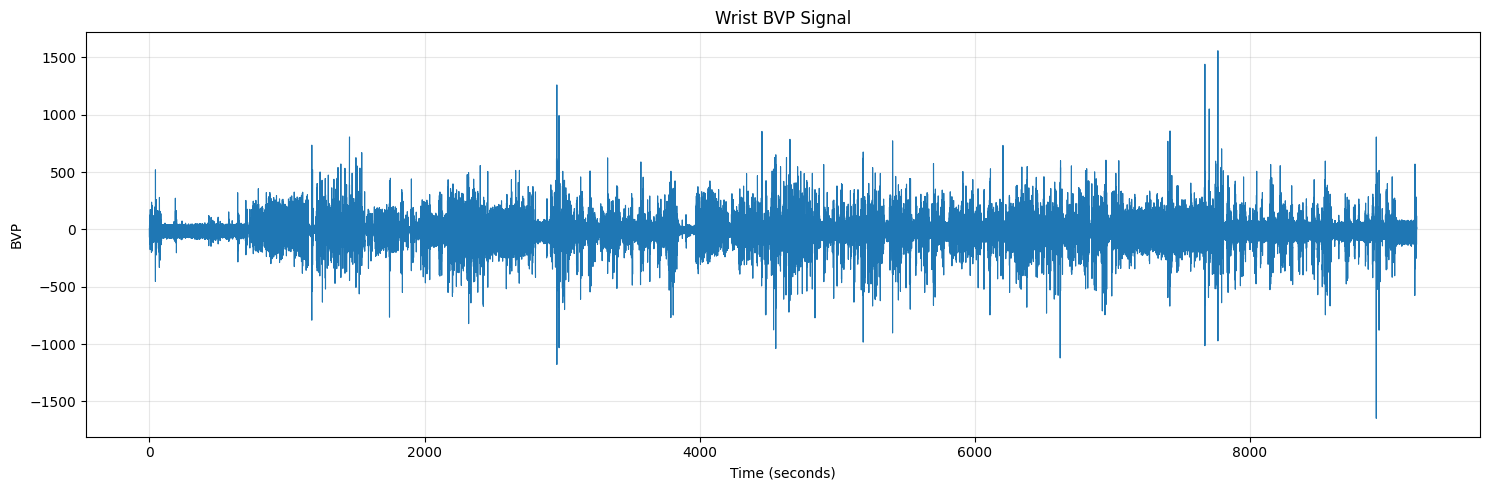

In [8]:
bvp = data["signal"]["wrist"]["BVP"].squeeze()
bvp_sampling_rate = 64
time_seconds = numpy.arange(len(bvp)) / bvp_sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time_seconds, bvp, linewidth=0.8)
plt.title("Wrist BVP Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("BVP")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
time_seconds

array([0.00000000e+00, 1.56250000e-02, 3.12500000e-02, ...,
       9.21195312e+03, 9.21196875e+03, 9.21198438e+03], shape=(589568,))

In [10]:
data['activity'].shape

(36848, 1)

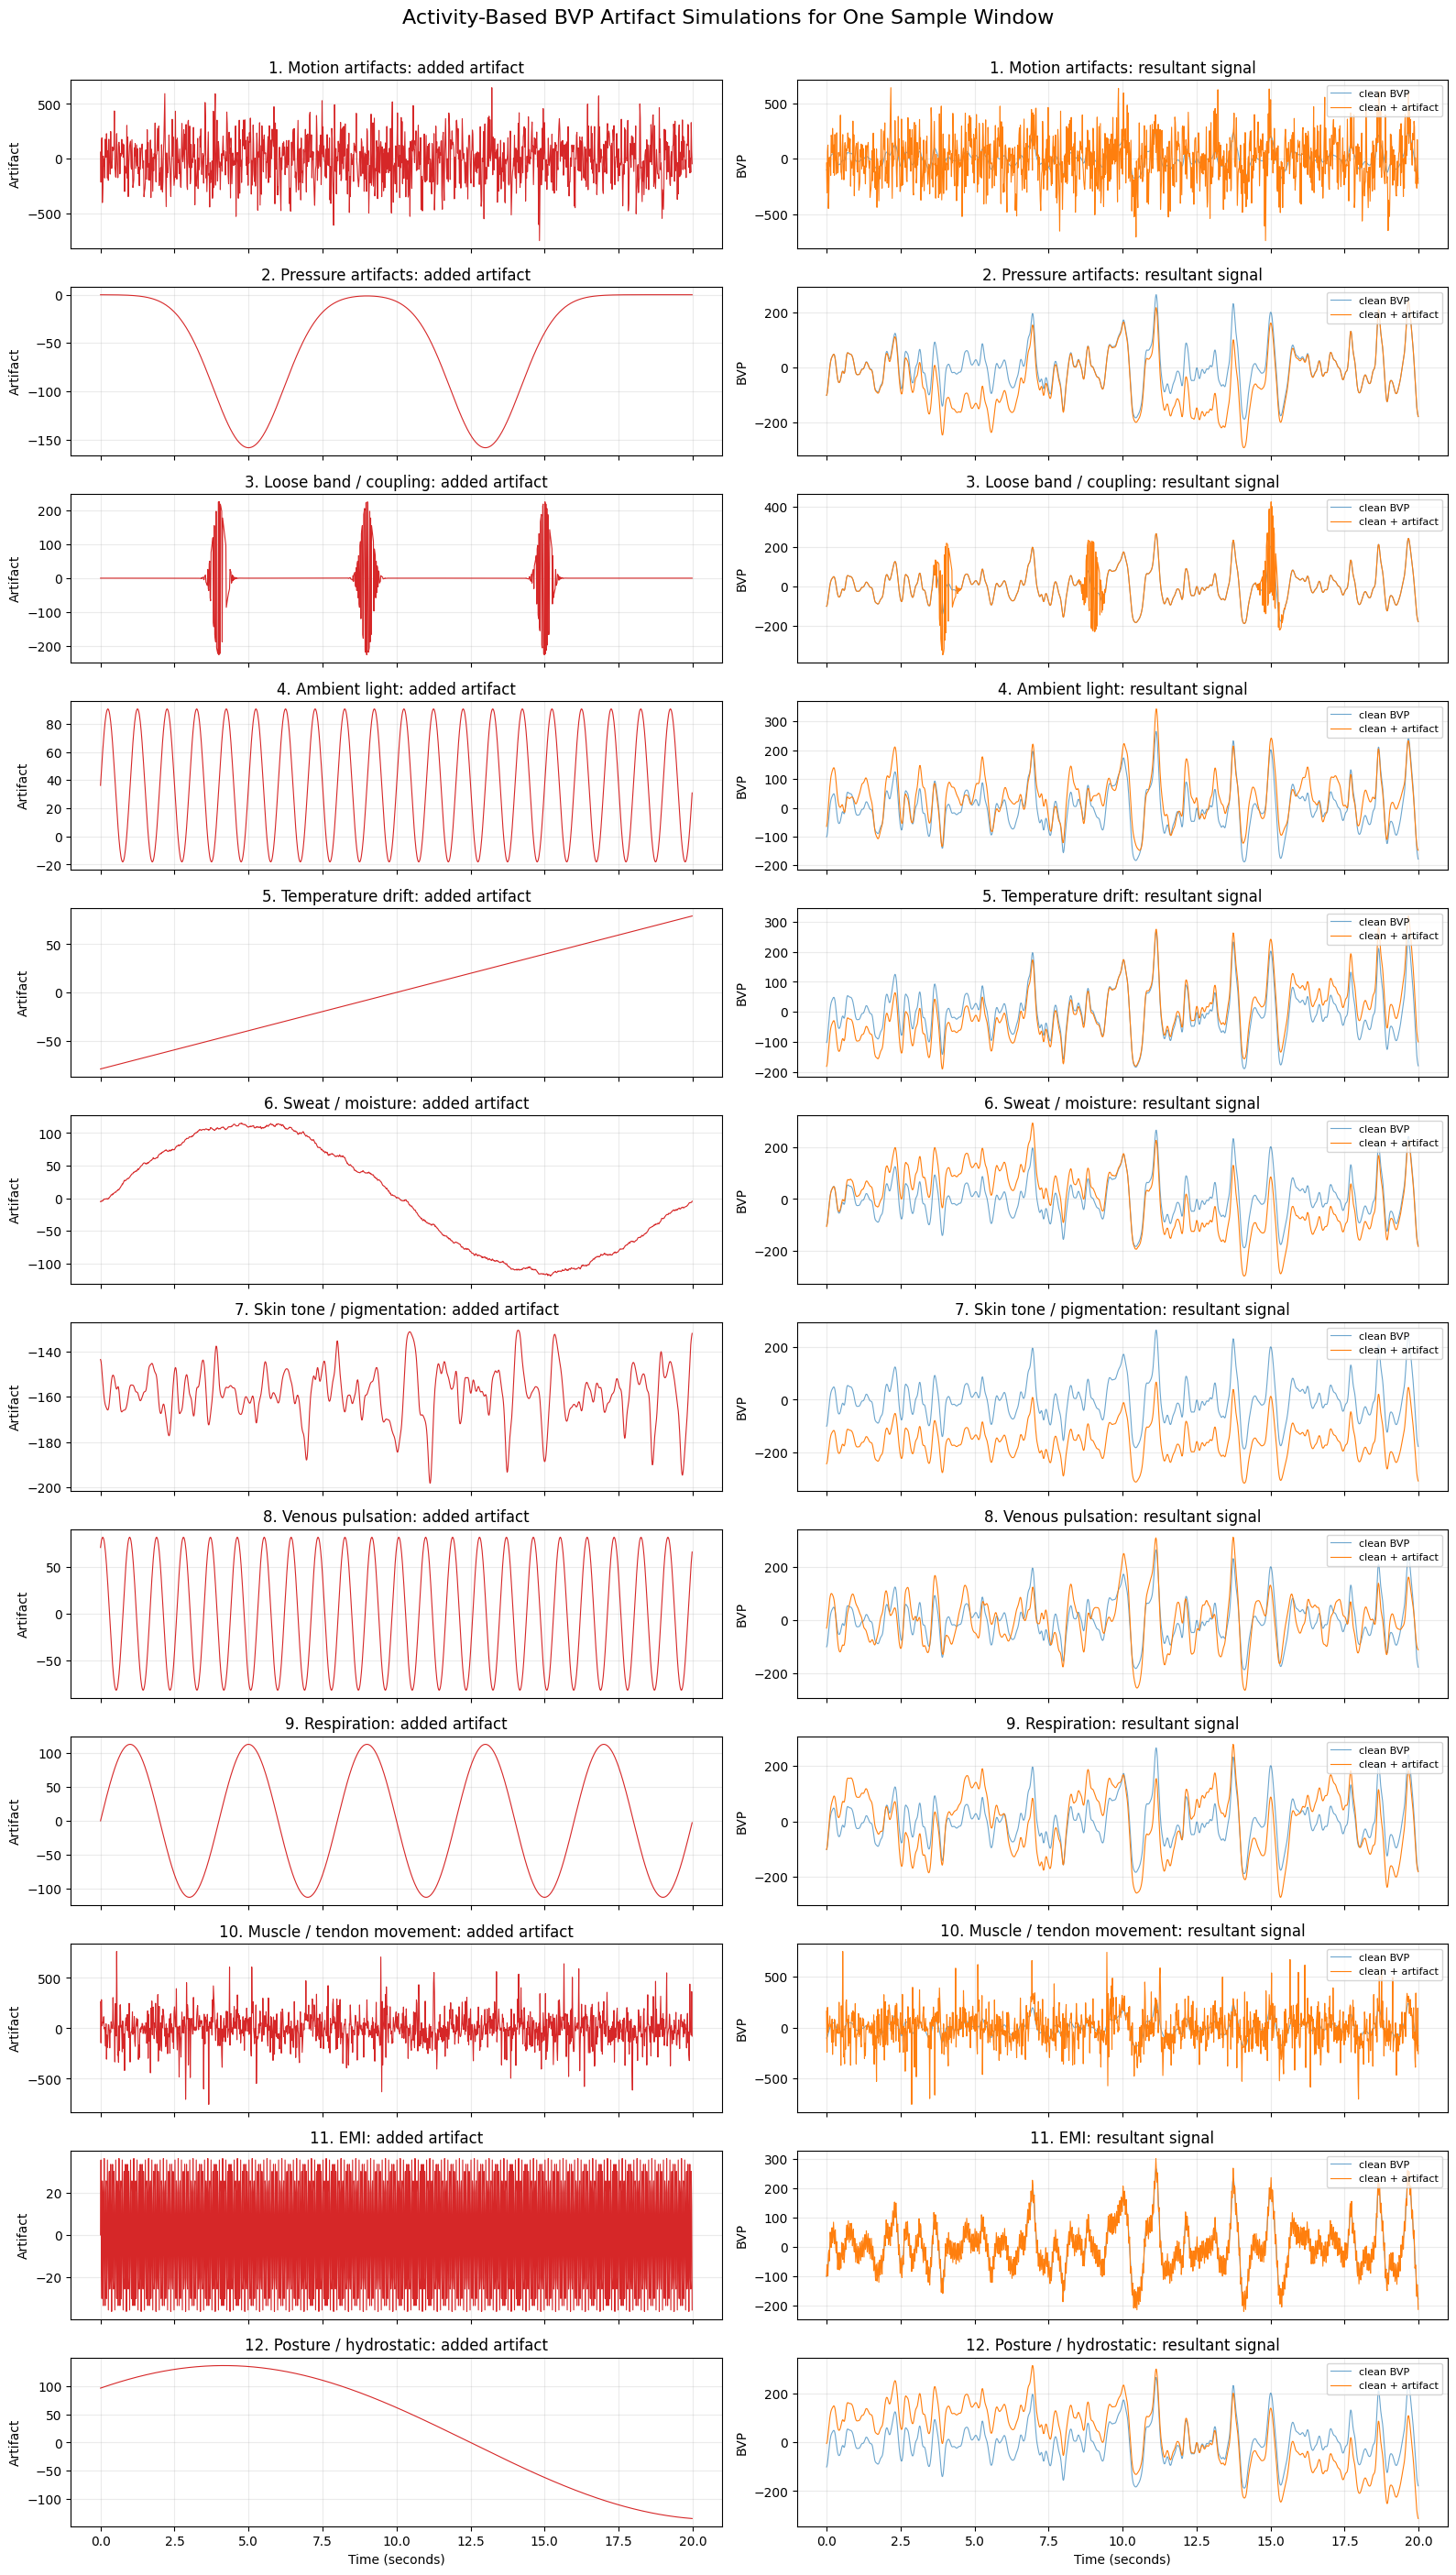

In [11]:
rng = numpy.random.default_rng(42)

bvp = data["signal"]["wrist"]["BVP"].squeeze()
activity = data["activity"].squeeze()

bvp_sampling_rate = 64
activity_sampling_rate = 4
sample_start_seconds = 1000
sample_duration_seconds = 20

start = sample_start_seconds * bvp_sampling_rate
stop = start + sample_duration_seconds * bvp_sampling_rate
clean_bvp = bvp[start:stop].astype(float)
t = numpy.arange(len(clean_bvp)) / bvp_sampling_rate

activity_start = sample_start_seconds * activity_sampling_rate
activity_stop = activity_start + sample_duration_seconds * activity_sampling_rate
activity_sample = activity[activity_start:activity_stop].astype(float)
activity_time = numpy.arange(len(activity_sample)) / activity_sampling_rate
activity_envelope = numpy.interp(t, activity_time, activity_sample)

if numpy.ptp(activity_envelope) == 0:
    activity_envelope = numpy.ones_like(t)
else:
    activity_envelope = (activity_envelope - activity_envelope.min()) / numpy.ptp(activity_envelope)

signal_range = numpy.ptp(clean_bvp)
signal_std = clean_bvp.std()

def burst_mask(t, centers, width):
    mask = numpy.zeros_like(t)
    for center in centers:
        mask += numpy.exp(-0.5 * ((t - center) / width) ** 2)
    return numpy.clip(mask, 0, 1)

def smooth_noise(scale):
    noise = rng.normal(0, scale, len(t))
    window = max(3, bvp_sampling_rate // 2)
    kernel = numpy.ones(window) / window
    return numpy.convolve(noise, kernel, mode="same")

artifact_models = {
    "1. Motion artifacts": 0.45 * signal_range * activity_envelope * rng.normal(0, 1, len(t)),
    "2. Pressure artifacts": -0.35 * signal_range * burst_mask(t, [5, 13], 1.2),
    "3. Loose band / coupling": 0.5 * signal_range * burst_mask(t, [4, 9, 15], 0.18) * rng.choice([-1, 1], len(t)),
    "4. Ambient light": 0.12 * signal_range * numpy.sin(2 * numpy.pi * 1.0 * t) + 0.08 * signal_range,
    "5. Temperature drift": 0.35 * signal_range * (t / t.max() - 0.5),
    "6. Sweat / moisture": 0.25 * signal_range * numpy.sin(2 * numpy.pi * 0.05 * t) + smooth_noise(0.04 * signal_range),
    "7. Skin tone / pigmentation": -0.35 * signal_range * numpy.ones_like(t) + 0.15 * (clean_bvp.mean() - clean_bvp),
    "8. Venous pulsation": 0.18 * signal_range * numpy.sin(2 * numpy.pi * 1.1 * t + numpy.pi / 3),
    "9. Respiration": 0.25 * signal_range * numpy.sin(2 * numpy.pi * 0.25 * t),
    "10. Muscle / tendon movement": 0.25 * signal_range * activity_envelope * rng.laplace(0, 1, len(t)),
    "11. EMI": 0.08 * signal_range * numpy.sin(2 * numpy.pi * 18 * t),
    "12. Posture / hydrostatic": 0.3 * signal_range * numpy.sin(2 * numpy.pi * 0.03 * t + numpy.pi / 4),
}

fig, axes = plt.subplots(len(artifact_models), 2, figsize=(16, 28), sharex=True)

for row, (artifact_name, artifact_noise) in enumerate(artifact_models.items()):
    noisy_bvp = clean_bvp + artifact_noise

    axes[row, 0].plot(t, artifact_noise, color="tab:red", linewidth=0.8)
    axes[row, 0].set_title(f"{artifact_name}: added artifact")
    axes[row, 0].set_ylabel("Artifact")
    axes[row, 0].grid(True, alpha=0.25)

    axes[row, 1].plot(t, clean_bvp, color="tab:blue", linewidth=0.8, alpha=0.65, label="clean BVP")
    axes[row, 1].plot(t, noisy_bvp, color="tab:orange", linewidth=0.8, label="clean + artifact")
    axes[row, 1].set_title(f"{artifact_name}: resultant signal")
    axes[row, 1].set_ylabel("BVP")
    axes[row, 1].grid(True, alpha=0.25)
    axes[row, 1].legend(loc="upper right", fontsize=8)

axes[-1, 0].set_xlabel("Time (seconds)")
axes[-1, 1].set_xlabel("Time (seconds)")
fig.suptitle("Activity-Based BVP Artifact Simulations for One Sample Window", y=1.002, fontsize=16)
plt.tight_layout()
plt.show()

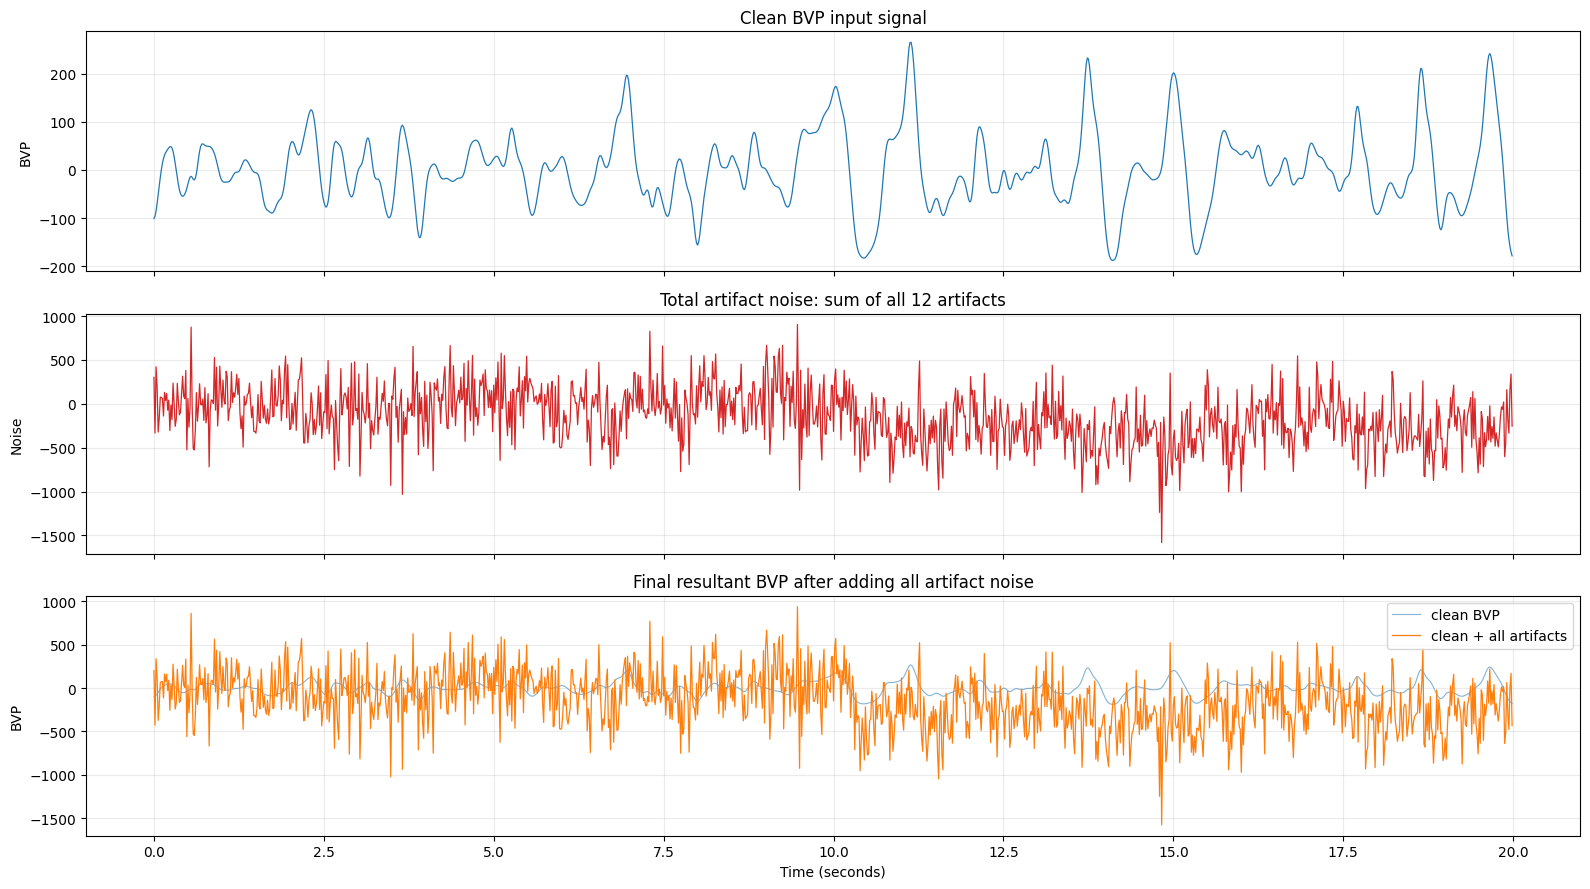

In [12]:
total_artifact_noise = numpy.sum(numpy.vstack(list(artifact_models.values())), axis=0)
final_noisy_bvp = clean_bvp + total_artifact_noise

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(t, clean_bvp, color="tab:blue", linewidth=0.9)
axes[0].set_title("Clean BVP input signal")
axes[0].set_ylabel("BVP")
axes[0].grid(True, alpha=0.25)

axes[1].plot(t, total_artifact_noise, color="tab:red", linewidth=0.9)
axes[1].set_title("Total artifact noise: sum of all 12 artifacts")
axes[1].set_ylabel("Noise")
axes[1].grid(True, alpha=0.25)

axes[2].plot(t, clean_bvp, color="tab:blue", linewidth=0.8, alpha=0.55, label="clean BVP")
axes[2].plot(t, final_noisy_bvp, color="tab:orange", linewidth=0.9, label="clean + all artifacts")
axes[2].set_title("Final resultant BVP after adding all artifact noise")
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("BVP")
axes[2].grid(True, alpha=0.25)
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [13]:
heart_rate_data_dir = Path("/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data")

bvp_sampling_rate = 64
activity_sampling_rate = 4
label_sampling_rate = 0.5

sample_duration_seconds = int(1 / label_sampling_rate)
bvp_samples_per_label = bvp_sampling_rate * sample_duration_seconds
activity_samples_per_label = activity_sampling_rate * sample_duration_seconds

subject_files = sorted(heart_rate_data_dir.glob("S*/S*.pkl"), key=lambda path: int(path.stem[1:]))

print(f"Found {len(subject_files)} subject files")
print(f"Each dataset sample = {sample_duration_seconds} seconds = {bvp_samples_per_label} BVP points")
subject_files

Found 15 subject files
Each dataset sample = 2 seconds = 128 BVP points


[PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S1/S1.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S2/S2.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S3/S3.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S4/S4.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S5/S5.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S6/S6.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S7/S7.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S8/S8.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S9/S9.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S10/S10.pkl'),
 PosixPath('/Users/ishananand/Desktop/Time-Serie

In [14]:
def make_burst_mask(t, centers, width):
    mask = numpy.zeros_like(t)
    for center in centers:
        mask += numpy.exp(-0.5 * ((t - center) / width) ** 2)
    return numpy.clip(mask, 0, 1)

def make_smooth_noise(rng, length, scale, window):
    noise = rng.normal(0, scale, length)
    kernel = numpy.ones(window) / window
    return numpy.convolve(noise, kernel, mode="same")

def normalize_activity(activity_window, target_length):
    activity_window = numpy.asarray(activity_window, dtype=float).squeeze()
    if len(activity_window) == 0:
        return numpy.ones(target_length)

    source_time = numpy.arange(len(activity_window)) / activity_sampling_rate
    target_time = numpy.arange(target_length) / bvp_sampling_rate
    envelope = numpy.interp(target_time, source_time, activity_window)

    if numpy.ptp(envelope) == 0:
        return numpy.ones_like(target_time)

    return (envelope - envelope.min()) / numpy.ptp(envelope)

def generate_artifacts_for_sample(clean_bvp, activity_window, rng):
    clean_bvp = numpy.asarray(clean_bvp, dtype=float).squeeze()
    t = numpy.arange(len(clean_bvp)) / bvp_sampling_rate
    activity_envelope = normalize_activity(activity_window, len(clean_bvp))

    signal_range = numpy.ptp(clean_bvp)
    if signal_range == 0:
        signal_range = max(clean_bvp.std(), 1.0)

    return {
        "motion_artifacts": 0.45 * signal_range * activity_envelope * rng.normal(0, 1, len(t)),
        "pressure_artifacts": -0.35 * signal_range * make_burst_mask(t, rng.uniform(0.3, 1.7, 2), rng.uniform(0.12, 0.35)),
        "loose_band_coupling": 0.5 * signal_range * make_burst_mask(t, rng.uniform(0.2, 1.8, 3), rng.uniform(0.03, 0.12)) * rng.choice([-1, 1], len(t)),
        "ambient_light": 0.12 * signal_range * numpy.sin(2 * numpy.pi * rng.uniform(0.8, 1.3) * t + rng.uniform(0, 2 * numpy.pi)) + rng.uniform(0.04, 0.1) * signal_range,
        "temperature_drift": rng.choice([-1, 1]) * rng.uniform(0.15, 0.35) * signal_range * (t / max(t.max(), 1 / bvp_sampling_rate) - 0.5),
        "sweat_moisture": 0.25 * signal_range * numpy.sin(2 * numpy.pi * rng.uniform(0.03, 0.08) * t + rng.uniform(0, 2 * numpy.pi)) + make_smooth_noise(rng, len(t), 0.04 * signal_range, max(3, bvp_sampling_rate // 2)),
        "skin_tone_pigmentation": -rng.uniform(0.2, 0.4) * signal_range * numpy.ones_like(t) + rng.uniform(0.08, 0.18) * (clean_bvp.mean() - clean_bvp),
        "venous_pulsation": rng.uniform(0.12, 0.22) * signal_range * numpy.sin(2 * numpy.pi * rng.uniform(0.8, 1.3) * t + rng.uniform(0, 2 * numpy.pi)),
        "respiration": rng.uniform(0.15, 0.3) * signal_range * numpy.sin(2 * numpy.pi * rng.uniform(0.15, 0.4) * t + rng.uniform(0, 2 * numpy.pi)),
        "muscle_tendon_movement": 0.25 * signal_range * activity_envelope * rng.laplace(0, 1, len(t)),
        "emi": rng.uniform(0.04, 0.1) * signal_range * numpy.sin(2 * numpy.pi * rng.uniform(15, 24) * t + rng.uniform(0, 2 * numpy.pi)),
        "posture_hydrostatic": rng.uniform(0.15, 0.3) * signal_range * numpy.sin(2 * numpy.pi * rng.uniform(0.02, 0.06) * t + rng.uniform(0, 2 * numpy.pi)),
    }

In [15]:
# Block 3: Build the full artifact dataset dictionary
artifact_dataset = {
    "metadata": {
        "source_dir": str(heart_rate_data_dir),
        "bvp_sampling_rate": bvp_sampling_rate,
        "activity_sampling_rate": activity_sampling_rate,
        "label_sampling_rate": label_sampling_rate,
        "sample_duration_seconds": sample_duration_seconds,
        "bvp_samples_per_sample": bvp_samples_per_label,
        "activity_samples_per_sample": activity_samples_per_label,
        "artifact_names": [
            "motion_artifacts",
            "pressure_artifacts",
            "loose_band_coupling",
            "ambient_light",
            "temperature_drift",
            "sweat_moisture",
            "skin_tone_pigmentation",
            "venous_pulsation",
            "respiration",
            "muscle_tendon_movement",
            "emi",
            "posture_hydrostatic",
        ],
    },
    "subjects": {},
}

base_seed = 20260615

for subject_index, subject_file in enumerate(subject_files):
    with open(subject_file, "rb") as f:
        subject_data = pickle.load(f, encoding="latin1")

    subject_id = subject_data["subject"]
    bvp_signal = subject_data["signal"]["wrist"]["BVP"].squeeze().astype(float)
    activity_signal = subject_data["activity"].squeeze().astype(float)
    labels = subject_data["label"].squeeze().astype(float)

    max_samples_from_bvp = len(bvp_signal) // bvp_samples_per_label
    max_samples_from_activity = len(activity_signal) // activity_samples_per_label
    n_samples = min(len(labels), max_samples_from_bvp, max_samples_from_activity)

    clean_samples = numpy.empty((n_samples, bvp_samples_per_label), dtype=numpy.float32)
    summed_noise_samples = numpy.empty_like(clean_samples)
    noisy_samples = numpy.empty_like(clean_samples)
    artifact_samples = {
        artifact_name: numpy.empty_like(clean_samples)
        for artifact_name in artifact_dataset["metadata"]["artifact_names"]
    }

    for sample_index in range(n_samples):
        bvp_start = sample_index * bvp_samples_per_label
        bvp_stop = bvp_start + bvp_samples_per_label
        activity_start = sample_index * activity_samples_per_label
        activity_stop = activity_start + activity_samples_per_label

        clean_sample = bvp_signal[bvp_start:bvp_stop]
        activity_window = activity_signal[activity_start:activity_stop]

        rng = numpy.random.default_rng(base_seed + subject_index * 1_000_000 + sample_index)
        artifacts = generate_artifacts_for_sample(clean_sample, activity_window, rng)
        summed_noise = numpy.sum(numpy.vstack(list(artifacts.values())), axis=0)
        noisy_sample = clean_sample + summed_noise

        clean_samples[sample_index] = clean_sample.astype(numpy.float32)
        summed_noise_samples[sample_index] = summed_noise.astype(numpy.float32)
        noisy_samples[sample_index] = noisy_sample.astype(numpy.float32)

        for artifact_name, artifact_signal in artifacts.items():
            artifact_samples[artifact_name][sample_index] = artifact_signal.astype(numpy.float32)

    artifact_dataset["subjects"][subject_id] = {
        "source_file": str(subject_file),
        "actual_signal": clean_samples,
        "artifact_signals": artifact_samples,
        "summed_noise_signal": summed_noise_samples,
        "summed_signal": noisy_samples,
        "label": labels[:n_samples].astype(numpy.float32),
        "activity": activity_signal[: n_samples * activity_samples_per_label].reshape(n_samples, activity_samples_per_label).astype(numpy.float32),
    }

    print(f"{subject_id}: {n_samples} samples")

print("Done building artifact_dataset")

/var/folders/y8/q2s37ndx6tg3lpzp3vp8xk_r0000gn/T/ipykernel_13546/24338940.py:33: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  subject_data = pickle.load(f, encoding="latin1")


S1: 4603 samples
S2: 4099 samples
S3: 4367 samples
S4: 4572 samples
S5: 4649 samples
S6: 2622 samples
S7: 4668 samples
S8: 4037 samples
S9: 4277 samples
S10: 5321 samples
S11: 4521 samples
S12: 3954 samples
S13: 4565 samples
S14: 4476 samples
S15: 3966 samples
Done building artifact_dataset


In [16]:
# Block 4: Inspect the final dictionary
dataset_summary = {
    subject_id: {
        "actual_signal": subject_dataset["actual_signal"].shape,
        "each_artifact_signal": next(iter(subject_dataset["artifact_signals"].values())).shape,
        "summed_noise_signal": subject_dataset["summed_noise_signal"].shape,
        "summed_signal": subject_dataset["summed_signal"].shape,
        "label": subject_dataset["label"].shape,
        "activity": subject_dataset["activity"].shape,
    }
    for subject_id, subject_dataset in artifact_dataset["subjects"].items()
}

dataset_summary

{'S1': {'actual_signal': (4603, 128),
  'each_artifact_signal': (4603, 128),
  'summed_noise_signal': (4603, 128),
  'summed_signal': (4603, 128),
  'label': (4603,),
  'activity': (4603, 8)},
 'S2': {'actual_signal': (4099, 128),
  'each_artifact_signal': (4099, 128),
  'summed_noise_signal': (4099, 128),
  'summed_signal': (4099, 128),
  'label': (4099,),
  'activity': (4099, 8)},
 'S3': {'actual_signal': (4367, 128),
  'each_artifact_signal': (4367, 128),
  'summed_noise_signal': (4367, 128),
  'summed_signal': (4367, 128),
  'label': (4367,),
  'activity': (4367, 8)},
 'S4': {'actual_signal': (4572, 128),
  'each_artifact_signal': (4572, 128),
  'summed_noise_signal': (4572, 128),
  'summed_signal': (4572, 128),
  'label': (4572,),
  'activity': (4572, 8)},
 'S5': {'actual_signal': (4649, 128),
  'each_artifact_signal': (4649, 128),
  'summed_noise_signal': (4649, 128),
  'summed_signal': (4649, 128),
  'label': (4649,),
  'activity': (4649, 8)},
 'S6': {'actual_signal': (2622, 128

In [17]:
artifact_dataset["subjects"]["S1"]

{'source_file': '/Users/ishananand/Desktop/Time-Series/SignalProcessing/HeartRate_Data/S1/S1.pkl',
 'actual_signal': array([[   7.28,    6.33,    5.46, ...,   -6.34,   -1.46,    2.65],
        [   6.34,    9.78,   12.97, ...,   11.45,   10.43,    9.19],
        [   7.7 ,    6.02,    4.23, ..., -158.45, -147.23, -133.8 ],
        ...,
        [ 352.52,  208.6 ,   77.02, ..., -150.3 , -156.23, -158.42],
        [-155.18, -144.64, -125.15, ...,  -43.79,  -39.42,  -33.53],
        [ -25.97,  -16.65,   -5.75, ..., -171.37, -198.81, -224.57]],
       shape=(4603, 128), dtype=float32),
 'artifact_signals': {'motion_artifacts': array([[  20.956226,  -76.00925 ,  -13.467868, ...,    2.155494,
            74.985565,  -28.553844],
         [ -10.17126 ,  -15.234645,   31.186634, ...,  -64.37548 ,
           -58.537216,  -56.952267],
         [ -99.16562 , -259.9946  ,  -66.409904, ...,   81.28121 ,
            40.853287,  140.46466 ],
         ...,
         [-323.07144 ,   77.14051 ,  608.93524 ,

In [18]:
# Block 6: Create model-ready X, Y, and LABEL arrays
# X = noisy input BVP after adding all artifact noise
# Y = actual clean BVP signal
# LABEL = actual heart-rate ground truth label, kept only for future applications

X = numpy.concatenate(
    [subject_dataset["summed_signal"] for subject_dataset in artifact_dataset["subjects"].values()],
    axis=0,
).astype(numpy.float32)

Y = numpy.concatenate(
    [subject_dataset["actual_signal"] for subject_dataset in artifact_dataset["subjects"].values()],
    axis=0,
).astype(numpy.float32)

LABEL = numpy.concatenate(
    [subject_dataset["label"] for subject_dataset in artifact_dataset["subjects"].values()],
    axis=0,
).astype(numpy.float32)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("LABEL shape:", LABEL.shape)

X shape: (64697, 128)
Y shape: (64697, 128)
LABEL shape: (64697,)


## Denoising methods

The next blocks implement denoising methods step by step. The denoising task is only `X -> Y`: noisy PPG input to actual clean PPG output. `LABEL` is not used here.

In [19]:
# Block 7: Shared preparation for denoising methods

NOISE = (X - Y).astype(numpy.float32)

split_rng = numpy.random.default_rng(123)
indices = split_rng.permutation(len(X))

train_end = int(0.70 * len(indices))
val_end = int(0.85 * len(indices))

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, Y_train, NOISE_train = X[train_idx], Y[train_idx], NOISE[train_idx]
X_val, Y_val, NOISE_val = X[val_idx], Y[val_idx], NOISE[val_idx]
X_test, Y_test, NOISE_test = X[test_idx], Y[test_idx], NOISE[test_idx]

x_mean = X_train.mean()
x_std = X_train.std() + 1e-8

def standardize_signal_array(signal_array):
    return ((signal_array - x_mean) / x_std).astype(numpy.float32)

def unstandardize_signal_array(signal_array):
    return (signal_array * x_std + x_mean).astype(numpy.float32)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (45287, 128) Val: (9705, 128) Test: (9705, 128)


In [20]:
# Block 8: Plotting and metric helpers
def signal_mse(predicted, target):
    return float(numpy.mean((predicted - target) ** 2))

def signal_mae(predicted, target):
    return float(numpy.mean(numpy.abs(predicted - target)))

def plot_denoising_result(noisy_signal, denoised_signal, clean_signal, title):
    t = numpy.arange(len(clean_signal)) / bvp_sampling_rate

    plt.figure(figsize=(14, 4))
    plt.plot(t, noisy_signal, label="noisy input", linewidth=0.9, alpha=0.65)
    plt.plot(t, denoised_signal, label="denoised output", linewidth=1.0)
    plt.plot(t, clean_signal, label="actual clean PPG", linewidth=0.9, alpha=0.75)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("BVP")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

## Method 1: EMD / EEMD / CEEMDAN + adaptive filtering

In [102]:
# Block 9: EMD utilities
from scipy.interpolate import CubicSpline
from scipy.signal import find_peaks

def _spline_envelope(signal, extrema_indices):
    extrema_indices = numpy.unique(numpy.concatenate(([0], extrema_indices, [len(signal) - 1])))
    extrema_values = signal[extrema_indices]

    if len(extrema_indices) < 4:
        return numpy.interp(numpy.arange(len(signal)), extrema_indices, extrema_values)

    return CubicSpline(extrema_indices, extrema_values, bc_type="natural")(numpy.arange(len(signal)))

def emd_decompose(signal, max_imfs=5, max_siftings=10, stop_threshold=0.05):
    signal = numpy.asarray(signal, dtype=float).squeeze()
    residual = signal.copy()
    imfs = []

    for _ in range(max_imfs):
        h = residual.copy()

        for _ in range(max_siftings):
            maxima, _ = find_peaks(h)
            minima, _ = find_peaks(-h)

            if len(maxima) < 2 or len(minima) < 2:
                break

            upper = _spline_envelope(h, maxima)
            lower = _spline_envelope(h, minima)
            mean_envelope = 0.5 * (upper + lower)
            previous_h = h.copy()
            h = h - mean_envelope

            sift_change = numpy.sum((previous_h - h) ** 2) / (numpy.sum(previous_h ** 2) + 1e-8)
            if sift_change < stop_threshold:
                break

        maxima, _ = find_peaks(residual)
        minima, _ = find_peaks(-residual)
        if len(maxima) + len(minima) < 3:
            break

        imfs.append(h)
        residual = residual - h

    return imfs, residual

def estimate_noise_from_imfs(imfs, residual, signal_length):
    if len(imfs) == 0:
        return numpy.zeros(signal_length)

    zero_crossing_rates = []
    for imf in imfs:
        zero_crossings = numpy.sum(numpy.diff(numpy.signbit(imf)) != 0)
        zero_crossing_rates.append(zero_crossings / len(imf))

    threshold = numpy.median(zero_crossing_rates)
    noisy_imfs = [imf for imf, rate in zip(imfs, zero_crossing_rates) if rate >= threshold]

    if len(noisy_imfs) == 0:
        return numpy.zeros(signal_length)

    return numpy.sum(numpy.vstack(noisy_imfs), axis=0)

In [103]:
# Block 10: Adaptive filtering and Method 1 inference
def lms_adaptive_noise_cancel(primary_signal, reference_noise, filter_order=8, mu=0.05):
    primary_signal = numpy.asarray(primary_signal, dtype=float).squeeze()
    reference_noise = numpy.asarray(reference_noise, dtype=float).squeeze()

    weights = numpy.zeros(filter_order)
    padded_reference = numpy.pad(reference_noise, (filter_order - 1, 0))
    denoised = numpy.zeros_like(primary_signal)
    estimated_noise = numpy.zeros_like(primary_signal)

    for n in range(len(primary_signal)):
        reference_vector = padded_reference[n:n + filter_order][::-1]
        estimated_noise[n] = numpy.dot(weights, reference_vector)
        denoised[n] = primary_signal[n] - estimated_noise[n]
        normalization = numpy.dot(reference_vector, reference_vector) + 1e-8
        weights += (mu / normalization) * denoised[n] * reference_vector

    return denoised, estimated_noise

def method1_denoise_signal(noisy_signal, reference_noise=None, decomposition="emd", ensemble_size=8, noise_width=0.05):
    noisy_signal = numpy.asarray(noisy_signal, dtype=float).squeeze()

    def single_pass(signal_to_decompose):
        imfs, residual = emd_decompose(signal_to_decompose)
        imf_noise_reference = estimate_noise_from_imfs(imfs, residual, len(noisy_signal))
        adaptive_reference = reference_noise if reference_noise is not None else imf_noise_reference
        denoised, _ = lms_adaptive_noise_cancel(noisy_signal, adaptive_reference)
        return denoised

    if decomposition == "emd":
        return single_pass(noisy_signal).astype(numpy.float32)

    ensemble_rng = numpy.random.default_rng(777)
    sigma = noise_width * (numpy.std(noisy_signal) + 1e-8)
    denoised_members = []

    for _ in range(ensemble_size):
        added_noise = ensemble_rng.normal(0, sigma, len(noisy_signal))
        if decomposition == "eemd":
            denoised_members.append(single_pass(noisy_signal + added_noise))
        elif decomposition == "ceemdan":
            denoised_members.append(single_pass(noisy_signal + added_noise))
            denoised_members.append(single_pass(noisy_signal - added_noise))
        else:
            raise ValueError("decomposition must be 'emd', 'eemd', or 'ceemdan'")

    return numpy.mean(numpy.vstack(denoised_members), axis=0).astype(numpy.float32)

def method1_denoise_batch(noisy_samples, reference_noise_samples=None, decomposition="emd"):
    outputs = []
    for sample_index, noisy_sample in enumerate(noisy_samples):
        reference_noise = None if reference_noise_samples is None else reference_noise_samples[sample_index]
        outputs.append(method1_denoise_signal(noisy_sample, reference_noise, decomposition=decomposition))
    return numpy.vstack(outputs).astype(numpy.float32)

Method 1 MSE: 51942.53125
Method 1 MAE: 184.6369171142578


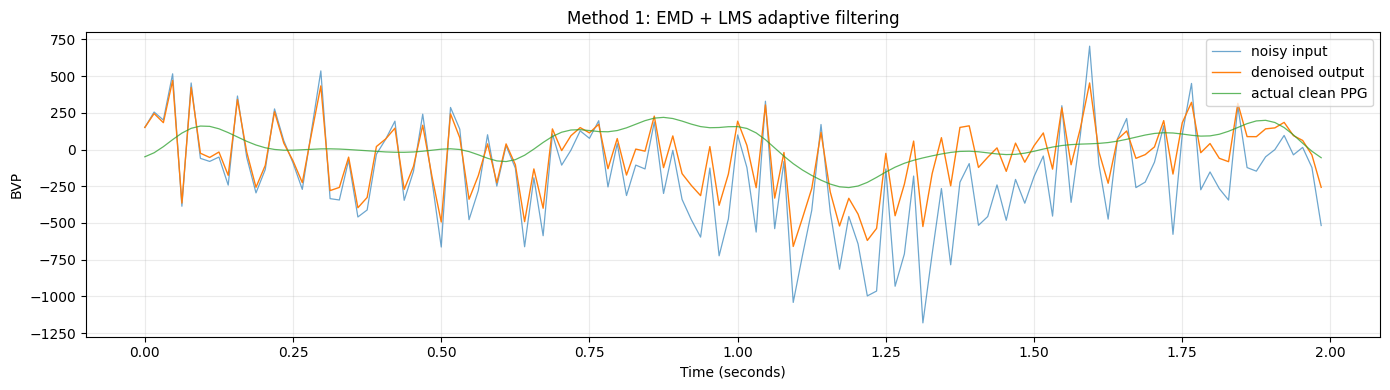

In [104]:
# Block 11: Method 1 example on one test sample
example_index = 0
method1_output = method1_denoise_signal(
    X_test[example_index],
    reference_noise=NOISE_test[example_index],
    decomposition="emd",
)

print("Method 1 MSE:", signal_mse(method1_output, Y_test[example_index]))
print("Method 1 MAE:", signal_mae(method1_output, Y_test[example_index]))
plot_denoising_result(X_test[example_index], method1_output, Y_test[example_index], "Method 1: EMD + LMS adaptive filtering")

## Method 2: CycleGAN

In [105]:
# CycleGAN dataset
class UnpairedSignalDataset(Dataset):
    def __init__(self, noisy_signals, clean_signals):
        self.noisy = torch.tensor(standardize_signal_array(noisy_signals), dtype=torch.float32).unsqueeze(1)
        self.clean = torch.tensor(standardize_signal_array(clean_signals), dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return max(len(self.noisy), len(self.clean))

    def __getitem__(self, index):
        noisy_index = index % len(self.noisy)
        clean_index = torch.randint(0, len(self.clean), (1,)).item()
        return self.noisy[noisy_index], self.clean[clean_index]

cyclegan_train_loader = DataLoader(
    UnpairedSignalDataset(X_train, Y_train),
    batch_size=128,
    shuffle=True,
    drop_last=True,
)

In [106]:
# Block 13: CycleGAN 1D models
class ResBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=7, padding=3),
            nn.InstanceNorm1d(channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(channels, channels, kernel_size=7, padding=3),
            nn.InstanceNorm1d(channels),
        )

    def forward(self, x):
        return x + self.block(x)

class CycleGenerator1D(nn.Module):
    def __init__(self, channels=64, n_res_blocks=4):
        super().__init__()
        blocks = [
            nn.Conv1d(1, channels, kernel_size=7, padding=3),
            nn.InstanceNorm1d(channels),
            nn.ReLU(inplace=True),
        ]
        blocks += [ResBlock1D(channels) for _ in range(n_res_blocks)]
        blocks += [nn.Conv1d(channels, 1, kernel_size=7, padding=3)]
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)

class CycleDiscriminator1D(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, channels, kernel_size=7, stride=2, padding=3),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(channels, channels * 2, kernel_size=7, stride=2, padding=3),
            nn.InstanceNorm1d(channels * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(channels * 2, channels * 4, kernel_size=7, stride=2, padding=3),
            nn.InstanceNorm1d(channels * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(channels * 4, 1, kernel_size=7, padding=3),
        )

    def forward(self, x):
        return self.net(x)

In [107]:
# Block 14: CycleGAN training and inference helpers
def train_cyclegan(train_loader, epochs=5, lr=2e-4, lambda_cycle=10.0, lambda_identity=2.0):
    G_noisy_to_clean = CycleGenerator1D().to(device)
    G_clean_to_noisy = CycleGenerator1D().to(device)
    D_clean = CycleDiscriminator1D().to(device)
    D_noisy = CycleDiscriminator1D().to(device)

    generator_optimizer = torch.optim.Adam(
        list(G_noisy_to_clean.parameters()) + list(G_clean_to_noisy.parameters()),
        lr=lr,
        betas=(0.5, 0.999),
    )
    discriminator_optimizer = torch.optim.Adam(
        list(D_clean.parameters()) + list(D_noisy.parameters()),
        lr=lr,
        betas=(0.5, 0.999),
    )

    adversarial_loss = nn.MSELoss()
    reconstruction_loss = nn.L1Loss()
    history = []

    for epoch in range(epochs):
        running_generator_loss = 0.0
        running_discriminator_loss = 0.0

        for noisy_batch, clean_batch in train_loader:
            noisy_batch = noisy_batch.to(device)
            clean_batch = clean_batch.to(device)

            valid_clean = torch.ones_like(D_clean(clean_batch))
            valid_noisy = torch.ones_like(D_noisy(noisy_batch))
            fake_clean_target = torch.zeros_like(valid_clean)
            fake_noisy_target = torch.zeros_like(valid_noisy)

            generator_optimizer.zero_grad()
            fake_clean = G_noisy_to_clean(noisy_batch)
            fake_noisy = G_clean_to_noisy(clean_batch)
            reconstructed_noisy = G_clean_to_noisy(fake_clean)
            reconstructed_clean = G_noisy_to_clean(fake_noisy)
            identity_clean = G_noisy_to_clean(clean_batch)
            identity_noisy = G_clean_to_noisy(noisy_batch)

            generator_loss = (
                adversarial_loss(D_clean(fake_clean), valid_clean)
                + adversarial_loss(D_noisy(fake_noisy), valid_noisy)
                + lambda_cycle * reconstruction_loss(reconstructed_noisy, noisy_batch)
                + lambda_cycle * reconstruction_loss(reconstructed_clean, clean_batch)
                + lambda_identity * reconstruction_loss(identity_clean, clean_batch)
                + lambda_identity * reconstruction_loss(identity_noisy, noisy_batch)
            )
            generator_loss.backward()
            generator_optimizer.step()

            discriminator_optimizer.zero_grad()
            clean_loss = 0.5 * (
                adversarial_loss(D_clean(clean_batch), valid_clean)
                + adversarial_loss(D_clean(fake_clean.detach()), fake_clean_target)
            )
            noisy_loss = 0.5 * (
                adversarial_loss(D_noisy(noisy_batch), valid_noisy)
                + adversarial_loss(D_noisy(fake_noisy.detach()), fake_noisy_target)
            )
            discriminator_loss = clean_loss + noisy_loss
            discriminator_loss.backward()
            discriminator_optimizer.step()

            running_generator_loss += generator_loss.item()
            running_discriminator_loss += discriminator_loss.item()

        history.append({
            "epoch": epoch + 1,
            "generator_loss": running_generator_loss / len(train_loader),
            "discriminator_loss": running_discriminator_loss / len(train_loader),
        })
        print(history[-1])

    return {
        "G_noisy_to_clean": G_noisy_to_clean,
        "G_clean_to_noisy": G_clean_to_noisy,
        "D_clean": D_clean,
        "D_noisy": D_noisy,
        "history": history,
    }

def cyclegan_denoise(cyclegan_models, noisy_samples, batch_size=256):
    generator = cyclegan_models["G_noisy_to_clean"]
    generator.eval()
    outputs = []

    with torch.no_grad():
        standardized = standardize_signal_array(noisy_samples)
        for start in range(0, len(standardized), batch_size):
            batch = torch.tensor(standardized[start:start + batch_size], dtype=torch.float32).unsqueeze(1).to(device)
            denoised = generator(batch).squeeze(1).cpu().numpy()
            outputs.append(denoised)

    return unstandardize_signal_array(numpy.vstack(outputs))

{'epoch': 1, 'generator_loss': 10.174998785888844, 'discriminator_loss': 0.11100594642395338}
{'epoch': 2, 'generator_loss': 8.585499419031333, 'discriminator_loss': 0.12914446207349092}
{'epoch': 3, 'generator_loss': 7.400708705102418, 'discriminator_loss': 0.15765480433324242}
{'epoch': 4, 'generator_loss': 6.804514020428104, 'discriminator_loss': 0.1592686429577576}
{'epoch': 5, 'generator_loss': 6.388301903397774, 'discriminator_loss': 0.16430407751974235}
{'epoch': 6, 'generator_loss': 6.084405816648229, 'discriminator_loss': 0.16706992854646516}
{'epoch': 7, 'generator_loss': 5.9444487885105035, 'discriminator_loss': 0.1727217105098554}
{'epoch': 8, 'generator_loss': 5.759078239246401, 'discriminator_loss': 0.16954549425215626}
{'epoch': 9, 'generator_loss': 5.604593413409701, 'discriminator_loss': 0.17338758871676901}
{'epoch': 10, 'generator_loss': 5.5112123664985635, 'discriminator_loss': 0.17675876093991416}
{'epoch': 11, 'generator_loss': 5.4478560561161204, 'discriminator_l

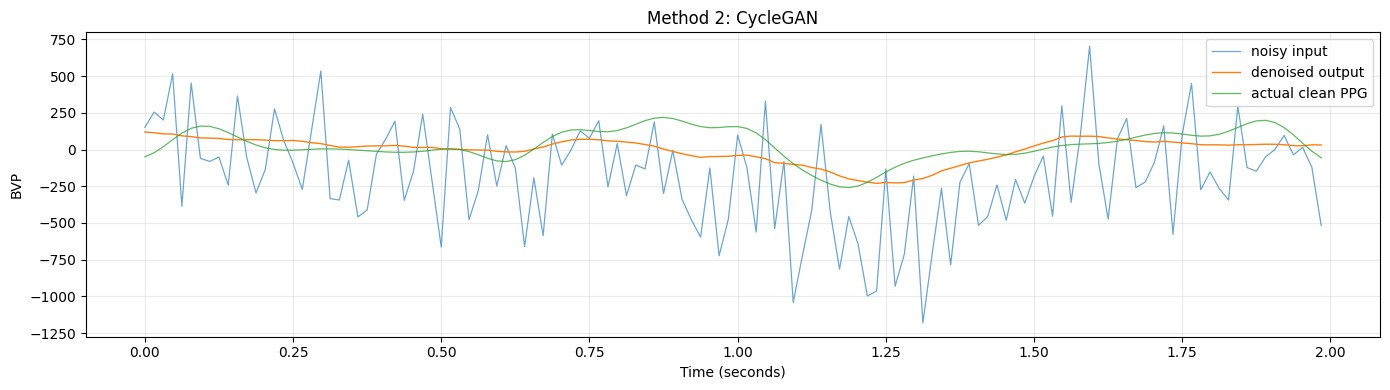

In [108]:
cyclegan_models = train_cyclegan(cyclegan_train_loader, epochs=30)
cyclegan_output = cyclegan_denoise(cyclegan_models, X_test)
print("CycleGAN test subset MSE:", signal_mse(cyclegan_output, Y_test))
print("CycleGAN test subset MAE:", signal_mae(cyclegan_output, Y_test))

plot_denoising_result(X_test[0], cyclegan_output[0], Y_test[0], "Method 2: CycleGAN")

## Method 3: FCGAN

In [109]:
# Block 16: FCGAN PyTorch setup, paired dataset, and models

# FCGAN paired dataset and models
class PairedSignalDataset(Dataset):
    def __init__(self, noisy_signals, clean_signals):
        self.noisy = torch.tensor(standardize_signal_array(noisy_signals), dtype=torch.float32).unsqueeze(1)
        self.clean = torch.tensor(standardize_signal_array(clean_signals), dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.noisy)

    def __getitem__(self, index):
        return self.noisy[index], self.clean[index]

class FCGANGenerator1D(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(channels, channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(channels, channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(channels, 1, kernel_size=9, padding=4),
        )

    def forward(self, noisy):
        predicted_residual = self.net(noisy)
        return noisy - predicted_residual

class FCGANDiscriminator1D(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(2, channels, kernel_size=7, stride=2, padding=3),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(channels, channels * 2, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(channels * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(channels * 2, channels * 4, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(channels * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(channels * 4, 1, kernel_size=7, padding=3),
        )

    def forward(self, noisy, clean_or_generated):
        return self.net(torch.cat([noisy, clean_or_generated], dim=1))

fcgan_train_loader = DataLoader(
    PairedSignalDataset(X_train, Y_train),
    batch_size=128,
    shuffle=True,
    drop_last=True,
)

In [110]:
# Block 17: FCGAN training and inference helpers
def train_fcgan(train_loader, epochs=5, lr=2e-4, lambda_l1=100.0):
    generator = FCGANGenerator1D().to(device)
    discriminator = FCGANDiscriminator1D().to(device)

    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    adversarial_loss = nn.MSELoss()
    reconstruction_loss = nn.L1Loss()
    history = []

    for epoch in range(epochs):
        running_generator_loss = 0.0
        running_discriminator_loss = 0.0

        for noisy_batch, clean_batch in train_loader:
            noisy_batch = noisy_batch.to(device)
            clean_batch = clean_batch.to(device)

            valid = torch.ones_like(discriminator(noisy_batch, clean_batch))
            fake = torch.zeros_like(valid)

            generator_optimizer.zero_grad()
            generated_clean = generator(noisy_batch)
            generator_loss = (
                adversarial_loss(discriminator(noisy_batch, generated_clean), valid)
                + lambda_l1 * reconstruction_loss(generated_clean, clean_batch)
            )
            generator_loss.backward()
            generator_optimizer.step()

            discriminator_optimizer.zero_grad()
            real_loss = adversarial_loss(discriminator(noisy_batch, clean_batch), valid)
            fake_loss = adversarial_loss(discriminator(noisy_batch, generated_clean.detach()), fake)
            discriminator_loss = 0.5 * (real_loss + fake_loss)
            discriminator_loss.backward()
            discriminator_optimizer.step()

            running_generator_loss += generator_loss.item()
            running_discriminator_loss += discriminator_loss.item()

        history.append({
            "epoch": epoch + 1,
            "generator_loss": running_generator_loss / len(train_loader),
            "discriminator_loss": running_discriminator_loss / len(train_loader),
        })
        print(history[-1])

    return {"generator": generator, "discriminator": discriminator, "history": history}

def fcgan_denoise(fcgan_models, noisy_samples, batch_size=256):
    generator = fcgan_models["generator"]
    generator.eval()
    outputs = []

    with torch.no_grad():
        standardized = standardize_signal_array(noisy_samples)
        for start in range(0, len(standardized), batch_size):
            batch = torch.tensor(standardized[start:start + batch_size], dtype=torch.float32).unsqueeze(1).to(device)
            denoised = generator(batch).squeeze(1).cpu().numpy()
            outputs.append(denoised)

    return unstandardize_signal_array(numpy.vstack(outputs))

{'epoch': 1, 'generator_loss': 20.57467163993684, 'discriminator_loss': 0.13521723046360626}
{'epoch': 2, 'generator_loss': 19.637332732549133, 'discriminator_loss': 0.023007290424626035}
{'epoch': 3, 'generator_loss': 19.422958298377882, 'discriminator_loss': 0.013646385839562493}
{'epoch': 4, 'generator_loss': 19.294236018367258, 'discriminator_loss': 0.01132024279940694}
{'epoch': 5, 'generator_loss': 19.28305144755766, 'discriminator_loss': 0.009837475306520677}
{'epoch': 6, 'generator_loss': 19.086331688986284, 'discriminator_loss': 0.007962353543375775}
{'epoch': 7, 'generator_loss': 19.152393821954053, 'discriminator_loss': 0.007557202846856613}
{'epoch': 8, 'generator_loss': 19.041266616950967, 'discriminator_loss': 0.007906743106973112}
{'epoch': 9, 'generator_loss': 18.96303843911579, 'discriminator_loss': 0.006313907747650282}
{'epoch': 10, 'generator_loss': 18.87501254095234, 'discriminator_loss': 0.0061640761480679885}
{'epoch': 11, 'generator_loss': 19.041873780593654, 'd

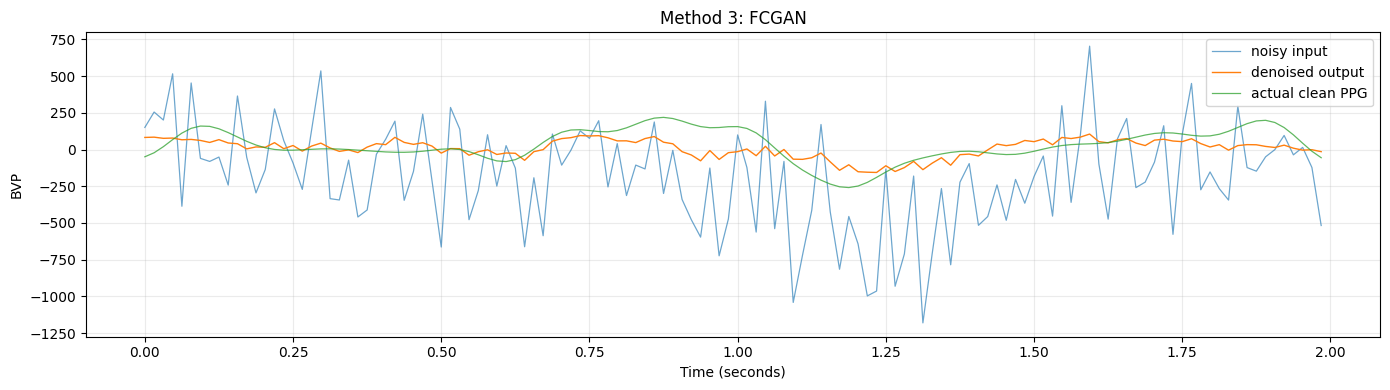

In [111]:
# Block 18: FCGAN run block
# Uncomment to train. Because FCGAN is paired, it should usually converge faster than CycleGAN here.
fcgan_models = train_fcgan(fcgan_train_loader, epochs=30)
fcgan_output = fcgan_denoise(fcgan_models, X_test)
print("FCGAN test subset MSE:", signal_mse(fcgan_output, Y_test))
print("FCGAN test subset MAE:", signal_mae(fcgan_output, Y_test))
plot_denoising_result(X_test[0], fcgan_output[0], Y_test[0], "Method 3: FCGAN")

## Method 4: VQVAE for PPG denoising

This VQVAE is adapted from the image version to one-dimensional PPG/BVP windows. It learns the paired denoising map `noisy PPG -> clean PPG` using `Conv1d`, a vector-quantized latent codebook, and a `ConvTranspose1d` decoder.

In [26]:
# Block 19: VQVAE paired PPG dataset and dataloaders

class PairedPPGDataset(Dataset):
    def __init__(self, noisy_signals, clean_signals):
        self.noisy = torch.tensor(standardize_signal_array(noisy_signals), dtype=torch.float32).unsqueeze(1)
        self.clean = torch.tensor(standardize_signal_array(clean_signals), dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.noisy)

    def __getitem__(self, index):
        return self.noisy[index], self.clean[index]

vqvae_train_loader = DataLoader(
    PairedPPGDataset(X_train, Y_train),
    batch_size=128,
    shuffle=True,
    drop_last=True,
)

vqvae_val_loader = DataLoader(
    PairedPPGDataset(X_val, Y_val),
    batch_size=256,
    shuffle=False,
)

vqvae_test_loader = DataLoader(
    PairedPPGDataset(X_test, Y_test),
    batch_size=256,
    shuffle=False,
)

In [27]:
# Block 20: VQVAE 1D model for PPG windows

class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
        )

    def forward(self, x):
        return x + self.block(x)

class VectorQuantizeSignal(nn.Module):
    def __init__(self, codebook_dim=128, embedding_dim=64, commitment_cost=0.25):
        super().__init__()
        self.codebook_dim = codebook_dim
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.codebook = nn.Embedding(codebook_dim, embedding_dim)
        self.codebook.weight.data.uniform_(-1.0 / codebook_dim, 1.0 / codebook_dim)

    def forward(self, encoded_signal):
        encoded_signal = encoded_signal.permute(0, 2, 1).contiguous()
        flat_encoded = encoded_signal.view(-1, self.embedding_dim)

        distances = (
            flat_encoded.pow(2).sum(dim=1, keepdim=True)
            - 2 * flat_encoded @ self.codebook.weight.t()
            + self.codebook.weight.pow(2).sum(dim=1)
        )

        encoding_indices = torch.argmin(distances, dim=1)
        quantized = self.codebook(encoding_indices).view_as(encoded_signal)

        codebook_loss = torch.mean((quantized - encoded_signal.detach()) ** 2)
        commitment_loss = torch.mean((quantized.detach() - encoded_signal) ** 2)
        quantize_loss = codebook_loss + self.commitment_cost * commitment_loss

        quantized = encoded_signal + (quantized - encoded_signal).detach()
        quantized = quantized.permute(0, 2, 1).contiguous()

        encoding_indices_cpu = encoding_indices.detach().cpu()
        avg_probs = torch.bincount(encoding_indices_cpu, minlength=self.codebook_dim).float()
        avg_probs = avg_probs / avg_probs.sum().clamp_min(1.0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        return quantized, quantize_loss, codebook_loss, commitment_loss, perplexity, encoding_indices

class VQVAEPPGDenoiser1D(nn.Module):
    def __init__(self, hidden_channels=64, embedding_dim=64, codebook_dim=128, commitment_cost=0.25):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, hidden_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(hidden_channels),
            ResidualBlock1D(hidden_channels),
            ResidualBlock1D(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_channels, embedding_dim, kernel_size=1),
        )
        self.vector_quantize = VectorQuantizeSignal(
            codebook_dim=codebook_dim,
            embedding_dim=embedding_dim,
            commitment_cost=commitment_cost,
        )
        self.decoder = nn.Sequential(
            nn.Conv1d(embedding_dim, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_channels),
            ResidualBlock1D(hidden_channels),
            ResidualBlock1D(hidden_channels),
            nn.ReLU(inplace=True),
            nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_channels, 1, kernel_size=7, padding=3),
        )

    def forward(self, noisy_signal):
        target_length = noisy_signal.shape[-1]
        encoded = self.encoder(noisy_signal)
        quantized, quantize_loss, codebook_loss, commitment_loss, perplexity, encoding_indices = self.vector_quantize(encoded)
        denoised = self.decoder(quantized)

        if denoised.shape[-1] != target_length:
            denoised = torch.nn.functional.interpolate(
                denoised,
                size=target_length,
                mode="linear",
                align_corners=False,
            )

        return {
            "denoised": denoised,
            "quantize_loss": quantize_loss,
            "codebook_loss": codebook_loss,
            "commitment_loss": commitment_loss,
            "perplexity": perplexity,
            "encoding_indices": encoding_indices,
        }

In [28]:
# Block 21: VQVAE training and validation helpers

def run_vqvae_epoch(model, data_loader, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_reconstruction_loss = 0.0
    total_codebook_loss = 0.0
    total_commitment_loss = 0.0
    total_perplexity = 0.0
    total_batches = 0

    for noisy_batch, clean_batch in data_loader:
        noisy_batch = noisy_batch.to(device)
        clean_batch = clean_batch.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            outputs = model(noisy_batch)
            reconstruction_loss = torch.mean(torch.abs(outputs["denoised"] - clean_batch))
            loss = reconstruction_loss + outputs["quantize_loss"]

            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        total_loss += loss.item()
        total_reconstruction_loss += reconstruction_loss.item()
        total_codebook_loss += outputs["codebook_loss"].item()
        total_commitment_loss += outputs["commitment_loss"].item()
        total_perplexity += outputs["perplexity"].item()
        total_batches += 1

    return {
        "loss": total_loss / total_batches,
        "reconstruction_l1": total_reconstruction_loss / total_batches,
        "codebook_loss": total_codebook_loss / total_batches,
        "commitment_loss": total_commitment_loss / total_batches,
        "perplexity": total_perplexity / total_batches,
    }

def vqvae_denoise(vqvae_model_or_result, noisy_samples, batch_size=256):
    model = vqvae_model_or_result["model"] if isinstance(vqvae_model_or_result, dict) else vqvae_model_or_result
    model.eval()
    outputs = []

    with torch.no_grad():
        standardized = standardize_signal_array(noisy_samples)
        for start in range(0, len(standardized), batch_size):
            batch = torch.tensor(standardized[start:start + batch_size], dtype=torch.float32).unsqueeze(1).to(device)
            denoised = model(batch)["denoised"].squeeze(1).cpu().numpy()
            outputs.append(denoised)

    return unstandardize_signal_array(numpy.vstack(outputs))

def evaluate_vqvae_mse(model, noisy_samples, clean_samples, batch_size=256):
    denoised = vqvae_denoise(model, noisy_samples, batch_size=batch_size)
    return signal_mse(denoised, clean_samples)

def evaluate_vqvae_mae(model, noisy_samples, clean_samples, batch_size=256):
    denoised = vqvae_denoise(model, noisy_samples, batch_size=batch_size)
    return signal_mae(denoised, clean_samples)

def train_vqvae_for_ppg(
    train_loader,
    val_loader=None,
    epochs=30,
    lr=2e-4,
    checkpoint_path="denoising_checkpoints/best_vqvae_ppg.pt",
    patience=6,
    min_delta=1e-4,
    hidden_channels=64,
    embedding_dim=64,
    codebook_dim=128,
    commitment_cost=0.25,
):
    if val_loader is None:
        val_loader = vqvae_val_loader

    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    model = VQVAEPPGDenoiser1D(
        hidden_channels=hidden_channels,
        embedding_dim=embedding_dim,
        codebook_dim=codebook_dim,
        commitment_cost=commitment_cost,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    best_val_mse = float("inf")
    best_val_mae = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_metrics = run_vqvae_epoch(model, train_loader, optimizer=optimizer)
        val_metrics = run_vqvae_epoch(model, val_loader, optimizer=None)
        val_mse = evaluate_vqvae_mse(model, X_val, Y_val)
        val_mae = evaluate_vqvae_mae(model, X_val, Y_val)
        improved = val_mse < best_val_mse - min_delta

        epoch_metrics = {
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_reconstruction_l1": train_metrics["reconstruction_l1"],
            "train_codebook_loss": train_metrics["codebook_loss"],
            "train_commitment_loss": train_metrics["commitment_loss"],
            "train_perplexity": train_metrics["perplexity"],
            "val_loss": val_metrics["loss"],
            "val_reconstruction_l1": val_metrics["reconstruction_l1"],
            "val_codebook_loss": val_metrics["codebook_loss"],
            "val_commitment_loss": val_metrics["commitment_loss"],
            "val_perplexity": val_metrics["perplexity"],
            "val_mse": val_mse,
            "val_mae": val_mae,
            "is_best": improved,
        }
        history.append(epoch_metrics)

        if improved:
            best_val_mse = val_mse
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            torch.save({
                "epoch": best_epoch,
                "best_val_mse": float(best_val_mse),
                "model": model.state_dict(),
                "history": history,
                "x_mean": float(x_mean),
                "x_std": float(x_std),
                "config": {
                    "hidden_channels": hidden_channels,
                    "embedding_dim": embedding_dim,
                    "codebook_dim": codebook_dim,
                    "commitment_cost": commitment_cost,
                },
            }, checkpoint_path)
        else:
            epochs_without_improvement += 1

        print(epoch_metrics)

        if epochs_without_improvement >= patience:
            print(f"Early stopping VQVAE at epoch {epoch + 1}. Best epoch: {best_epoch}, best val_mse: {best_val_mse:.6f}")
            break

    best_checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(best_checkpoint["model"])

    return {
        "model": model,
        "history": history,
        "best_epoch": best_checkpoint["epoch"],
        "best_val_mse": best_checkpoint["best_val_mse"],
        "checkpoint_path": str(checkpoint_path),
        "config": best_checkpoint["config"],
    }

{'epoch': 1, 'train_loss': 1.059302575865143, 'train_reconstruction_l1': 0.18922210596607358, 'train_codebook_loss': 0.6960643772194136, 'train_commitment_loss': 0.6960643772194136, 'train_perplexity': 9.79309338280567, 'val_loss': 0.619821172011526, 'val_reconstruction_l1': 0.16771558123199562, 'val_codebook_loss': 0.361684470584518, 'val_commitment_loss': 0.361684470584518, 'val_perplexity': 8.616942054346987, 'val_mse': 5223.4306640625, 'val_mae': 44.81795883178711, 'is_best': True}
{'epoch': 2, 'train_loss': 0.3856601214442645, 'train_reconstruction_l1': 0.1654442837066083, 'train_codebook_loss': 0.17617266922767033, 'train_commitment_loss': 0.17617266922767033, 'train_perplexity': 9.844766002201156, 'val_loss': 0.2975109995980012, 'val_reconstruction_l1': 0.16535888180920952, 'val_codebook_loss': 0.10572169387811109, 'val_commitment_loss': 0.10572169387811109, 'val_perplexity': 11.387749697032728, 'val_mse': 5101.24951171875, 'val_mae': 44.18788146972656, 'is_best': True}
{'epoch'

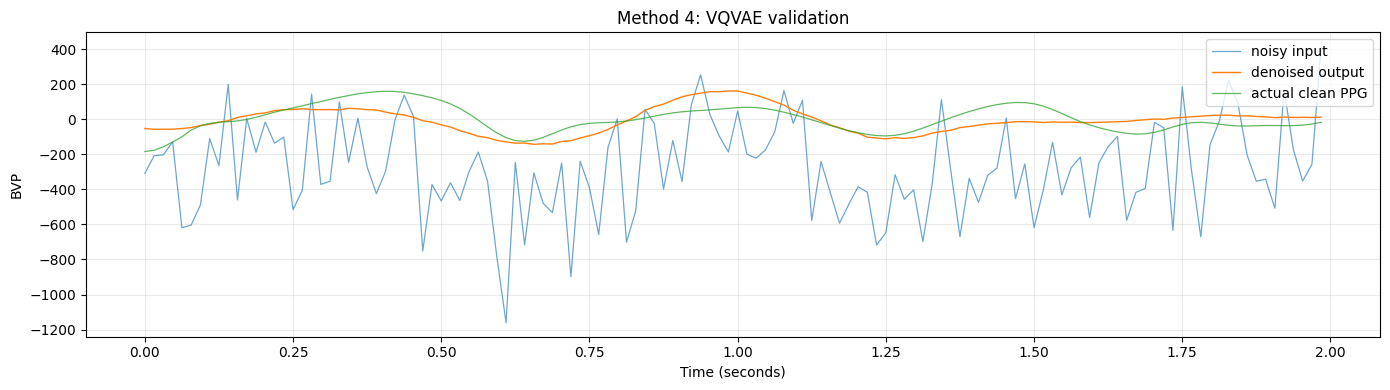

In [121]:
# Block 22: Train and validate VQVAE

vqvae_result = train_vqvae_for_ppg(
    vqvae_train_loader,
    val_loader=vqvae_val_loader,
    epochs=30,
    hidden_channels = 32, #64
    embedding_dim = 32, #64
    codebook_dim = 64, #128
)

vqvae_val_output = vqvae_denoise(vqvae_result, X_val)
print("VQVAE best epoch:", vqvae_result["best_epoch"])
print("VQVAE validation MSE:", signal_mse(vqvae_val_output, Y_val))
print("VQVAE validation MAE:", signal_mae(vqvae_val_output, Y_val))
plot_denoising_result(X_val[0], vqvae_val_output[0], Y_val[0], "Method 4: VQVAE validation")

VQVAE test subset MSE: 4990.5126953125
VQVAE test subset MAE: 43.18151092529297


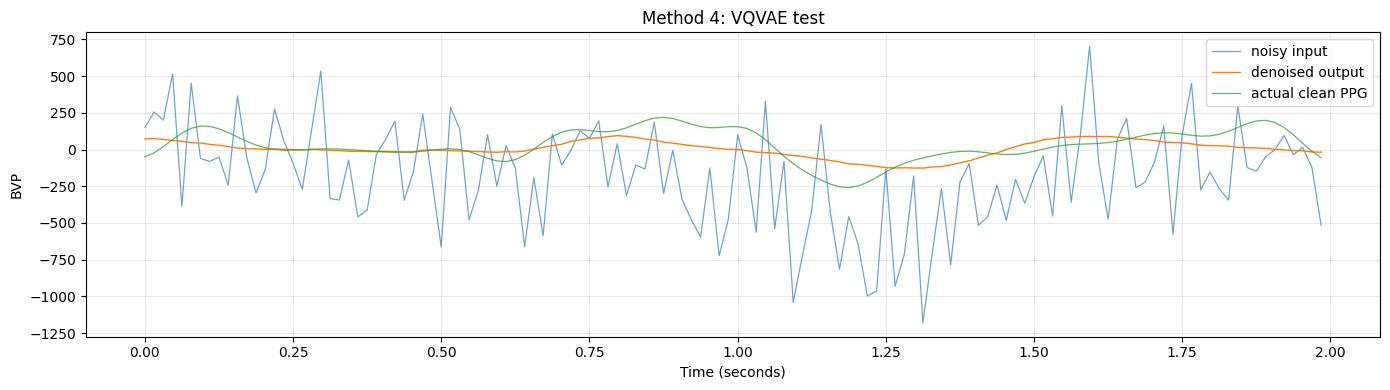

In [122]:
# Block 23: Test VQVAE

vqvae_test_output = vqvae_denoise(vqvae_result, X_test)
print("VQVAE test subset MSE:", signal_mse(vqvae_test_output, Y_test))
print("VQVAE test subset MAE:", signal_mae(vqvae_test_output, Y_test))
plot_denoising_result(X_test[0], vqvae_test_output[0], Y_test[0], "Method 4: VQVAE test")

VQVAE test subset MSE: 4990.5126953125
VQVAE test subset MAE: 43.18151092529297


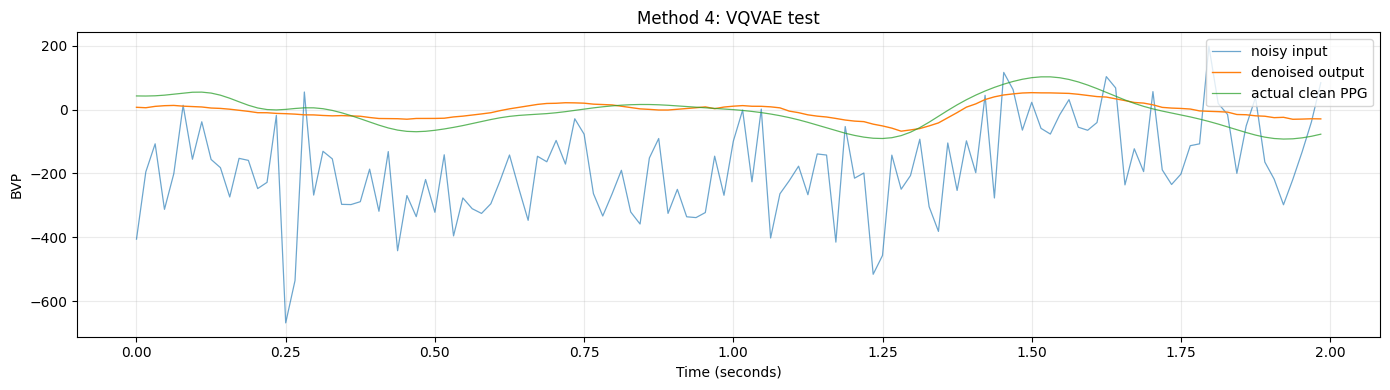

In [124]:
# Block 23: Test VQVAE

vqvae_test_output = vqvae_denoise(vqvae_result, X_test)
print("VQVAE test subset MSE:", signal_mse(vqvae_test_output, Y_test))
print("VQVAE test subset MAE:", signal_mae(vqvae_test_output, Y_test))
plot_denoising_result(X_test[2], vqvae_test_output[2], Y_test[2], "Method 4: VQVAE test")

## Method 5: 1D U-Net

A standard encoder-decoder with **skip connections** that directly bridge each encoder level to its matching decoder level. Unlike FCGAN (plain convolutions predict a residual) and VQVAE (discrete bottleneck, no lateral connections), the U-Net passes high-frequency local structure around the bottleneck via concatenation — this helps preserve PPG peak shape and fine temporal features that artifact noise corrupts.

In [29]:
# Block 24: U-Net dataloaders (reuse PairedPPGDataset defined in Method 4)

unet_train_loader = DataLoader(
    PairedPPGDataset(X_train, Y_train),
    batch_size=128,
    shuffle=True,
    drop_last=True,
)

unet_val_loader = DataLoader(
    PairedPPGDataset(X_val, Y_val),
    batch_size=256,
    shuffle=False,
)

unet_test_loader = DataLoader(
    PairedPPGDataset(X_test, Y_test),
    batch_size=256,
    shuffle=False,
)

In [30]:
# Block 25: 1D U-Net model
#
# Architecture for 128-sample BVP windows:
#   enc1: (B, 1,   128) -> (B,  32, 128)   stride-1 feature projection
#   enc2: (B, 32,  128) -> (B,  64,  64)   stride-2 downsample
#   enc3: (B, 64,   64) -> (B, 128,  32)   stride-2 downsample
#   enc4: (B, 128,  32) -> (B, 256,  16)   stride-2 downsample
#   bottleneck          -> (B, 256,  16)
#   dec3 + skip(enc3)  -> (B, 128,  32)
#   dec2 + skip(enc2)  -> (B,  64,  64)
#   dec1 + skip(enc1)  -> (B,  32, 128)
#   output             -> (B,   1, 128)

class UNet1DPPGDenoiser(nn.Module):
    def __init__(self, base_channels=32):
        super().__init__()
        c = base_channels

        self.enc1 = nn.Sequential(
            nn.Conv1d(1, c, kernel_size=7, padding=3),
            nn.BatchNorm1d(c),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv1d(c, c * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(c * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv1d(c * 2, c * 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(c * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv1d(c * 4, c * 8, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(c * 8),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv1d(c * 8, c * 8, kernel_size=3, padding=1),
            nn.BatchNorm1d(c * 8),
            nn.ReLU(inplace=True),
        )

        # Each decoder step: upsample then merge with skip via concat + conv
        self.up3  = nn.ConvTranspose1d(c * 8, c * 4, kernel_size=4, stride=2, padding=1)
        self.dec3 = nn.Sequential(
            nn.Conv1d(c * 8, c * 4, kernel_size=3, padding=1),
            nn.BatchNorm1d(c * 4),
            nn.ReLU(inplace=True),
        )

        self.up2  = nn.ConvTranspose1d(c * 4, c * 2, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.Sequential(
            nn.Conv1d(c * 4, c * 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(c * 2),
            nn.ReLU(inplace=True),
        )

        self.up1  = nn.ConvTranspose1d(c * 2, c, kernel_size=4, stride=2, padding=1)
        self.dec1 = nn.Sequential(
            nn.Conv1d(c * 2, c, kernel_size=3, padding=1),
            nn.BatchNorm1d(c),
            nn.ReLU(inplace=True),
        )

        self.output_conv = nn.Conv1d(c, 1, kernel_size=7, padding=3)

    def forward(self, x):
        e1 = self.enc1(x)           # (B, c,   128)
        e2 = self.enc2(e1)          # (B, 2c,   64)
        e3 = self.enc3(e2)          # (B, 4c,   32)
        e4 = self.enc4(e3)          # (B, 8c,   16)

        b = self.bottleneck(e4)     # (B, 8c,   16)

        d3 = self.up3(b)                             # (B, 4c, 32)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))  # (B, 4c, 32)

        d2 = self.up2(d3)                            # (B, 2c, 64)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))  # (B, 2c, 64)

        d1 = self.up1(d2)                            # (B,  c, 128)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))  # (B,  c, 128)

        return self.output_conv(d1)                  # (B,  1, 128)


# Quick sanity check
_dummy = torch.zeros(4, 1, 128)
_out   = UNet1DPPGDenoiser(base_channels=32)(_dummy)
print("U-Net output shape:", _out.shape)  # expect (4, 1, 128)
del _dummy, _out

U-Net output shape: torch.Size([4, 1, 128])


In [31]:
# Block 26: U-Net training and inference helpers

def unet_denoise(unet_model_or_result, noisy_samples, batch_size=256):
    model = unet_model_or_result["model"] if isinstance(unet_model_or_result, dict) else unet_model_or_result
    model.eval()
    outputs = []

    with torch.no_grad():
        standardized = standardize_signal_array(noisy_samples)
        for start in range(0, len(standardized), batch_size):
            batch = torch.tensor(standardized[start:start + batch_size], dtype=torch.float32).unsqueeze(1).to(device)
            denoised = model(batch).squeeze(1).cpu().numpy()
            outputs.append(denoised)

    return unstandardize_signal_array(numpy.vstack(outputs))


def _unet_evaluate(model, noisy_samples, clean_samples, batch_size=256):
    denoised = unet_denoise(model, noisy_samples, batch_size=batch_size)
    return signal_mse(denoised, clean_samples), signal_mae(denoised, clean_samples)


def train_unet_for_ppg(
    train_loader,
    val_loader=None,
    epochs=30,
    lr=1e-3,
    checkpoint_path="denoising_checkpoints/best_unet_ppg.pt",
    patience=6,
    min_delta=1e-4,
    base_channels=32,
):
    if val_loader is None:
        val_loader = unet_val_loader

    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    model = UNet1DPPGDenoiser(base_channels=base_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Halve lr if val_mse stalls for 3 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=3, factor=0.5, min_lr=1e-5
    )
    l1_loss = nn.L1Loss()

    history = []
    best_val_mse = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for noisy_batch, clean_batch in train_loader:
            noisy_batch = noisy_batch.to(device)
            clean_batch = clean_batch.to(device)
            optimizer.zero_grad()
            loss = l1_loss(model(noisy_batch), clean_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for noisy_batch, clean_batch in val_loader:
                val_loss += l1_loss(model(noisy_batch.to(device)), clean_batch.to(device)).item()
        val_loss /= len(val_loader)

        val_mse, val_mae = _unet_evaluate(model, X_val, Y_val)
        scheduler.step(val_mse)
        improved = val_mse < best_val_mse - min_delta

        epoch_metrics = {
            "epoch": epoch + 1,
            "train_l1": round(train_loss, 6),
            "val_l1": round(val_loss, 6),
            "val_mse": round(val_mse, 6),
            "val_mae": round(val_mae, 6),
            "lr": optimizer.param_groups[0]["lr"],
            "is_best": improved,
        }
        history.append(epoch_metrics)

        if improved:
            best_val_mse = val_mse
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            torch.save({
                "epoch": best_epoch,
                "best_val_mse": float(best_val_mse),
                "model": model.state_dict(),
                "history": history,
                "x_mean": float(x_mean),
                "x_std": float(x_std),
                "config": {"base_channels": base_channels},
            }, checkpoint_path)
        else:
            epochs_without_improvement += 1

        print(epoch_metrics)

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}. Best epoch: {best_epoch}, best val_mse: {best_val_mse:.6f}")
            break

    best_checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(best_checkpoint["model"])

    return {
        "model": model,
        "history": history,
        "best_epoch": best_checkpoint["epoch"],
        "best_val_mse": best_checkpoint["best_val_mse"],
        "checkpoint_path": str(checkpoint_path),
        "config": best_checkpoint["config"],
    }

{'epoch': 1, 'train_l1': 0.168174, 'val_l1': 0.162363, 'val_mse': 5009.944824, 'val_mae': 43.387604, 'lr': 0.001, 'is_best': True}
{'epoch': 2, 'train_l1': 0.161265, 'val_l1': 0.161861, 'val_mse': 4888.807617, 'val_mae': 43.252552, 'lr': 0.001, 'is_best': True}
{'epoch': 3, 'train_l1': 0.159773, 'val_l1': 0.159958, 'val_mse': 4786.555664, 'val_mae': 42.744148, 'lr': 0.001, 'is_best': True}
{'epoch': 4, 'train_l1': 0.159041, 'val_l1': 0.160948, 'val_mse': 4833.880371, 'val_mae': 43.008617, 'lr': 0.001, 'is_best': False}
{'epoch': 5, 'train_l1': 0.158551, 'val_l1': 0.159738, 'val_mse': 4742.869629, 'val_mae': 42.685352, 'lr': 0.001, 'is_best': True}
{'epoch': 6, 'train_l1': 0.158056, 'val_l1': 0.159714, 'val_mse': 4755.696777, 'val_mae': 42.678928, 'lr': 0.001, 'is_best': False}
{'epoch': 7, 'train_l1': 0.157966, 'val_l1': 0.159799, 'val_mse': 4752.700195, 'val_mae': 42.701855, 'lr': 0.001, 'is_best': False}
{'epoch': 8, 'train_l1': 0.157588, 'val_l1': 0.159587, 'val_mse': 4811.808594, '

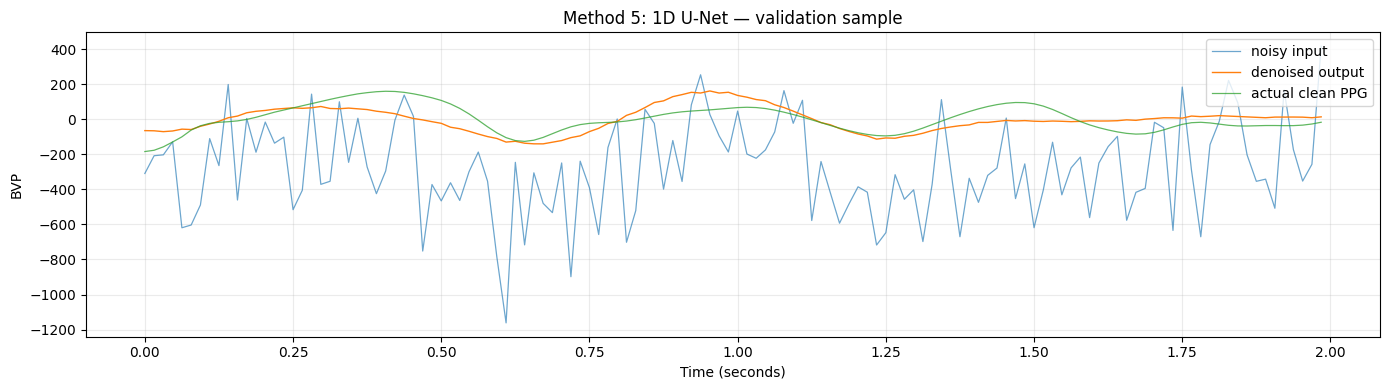

U-Net test MSE   : 4937.16064453125
U-Net test MAE   : 43.00822448730469


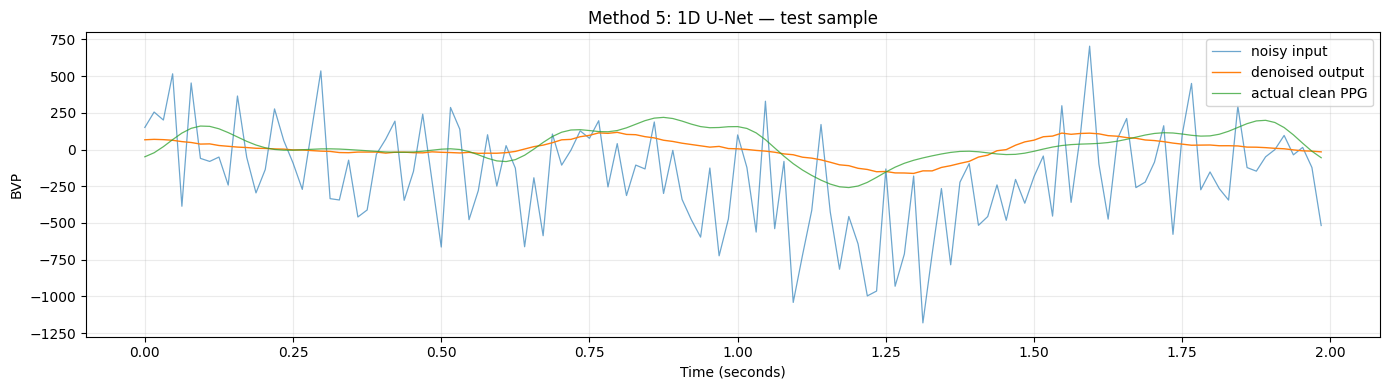

In [128]:
# Block 27: Train, validate, and test U-Net

unet_result = train_unet_for_ppg(
    unet_train_loader,
    val_loader=unet_val_loader,
    epochs=30,
    base_channels=32,
)

# Validation
unet_val_output = unet_denoise(unet_result, X_val)
print("U-Net best epoch :", unet_result["best_epoch"])
print("U-Net val MSE    :", signal_mse(unet_val_output, Y_val))
print("U-Net val MAE    :", signal_mae(unet_val_output, Y_val))
plot_denoising_result(X_val[0], unet_val_output[0], Y_val[0], "Method 5: 1D U-Net — validation sample")

# Test
unet_test_output = unet_denoise(unet_result, X_test)
print("U-Net test MSE   :", signal_mse(unet_test_output, Y_test))
print("U-Net test MAE   :", signal_mae(unet_test_output, Y_test))
plot_denoising_result(X_test[0], unet_test_output[0], Y_test[0], "Method 5: 1D U-Net — test sample")